# Phase 3 & 4 — Results Analysis

Cross-detector comparison for the synthetic phishing detection gap and the augmentation mitigation experiment.

**Detectors evaluated:**
- **SpamAssassin** (rule-based, 2000s-era industry standard)
- **Logistic Regression** (TF-IDF + LR, classical ML baseline)
- **XGBoost** (TF-IDF + gradient-boosted trees)
- **DistilBERT** (fine-tuned transformer)

**Structure:**
1. Load and consolidate results from all four detectors
2. Phase 3 — baseline detection gap (how badly do detectors miss AI-generated phishing?)
3. Where the gap lives — breakdown by generation method and scenario
4. Phase 4 — does augmentation close the gap? (ML detectors only)
5. Headline table for the writeup

All result CSVs must already be in `results/<detector>/` — run each detector's `eval.py` first.

## 1. Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Consistent styling for all figures
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

# Fixed color per detector — helps readers track them across multiple figures
DETECTOR_COLORS = {
    "spamassassin": "#7f7f7f",           # grey — rule-based baseline
    "logistic_regression": "#1f77b4",    # blue
    "xgboost": "#2ca02c",                # green
    "distilbert": "#d62728",             # red
}
DETECTOR_ORDER = ["spamassassin", "logistic_regression", "xgboost", "distilbert"]
DETECTOR_LABEL = {
    "spamassassin": "SpamAssassin",
    "logistic_regression": "Logistic Regression",
    "xgboost": "XGBoost",
    "distilbert": "DistilBERT",
}

# Auto-resolve repo root (so notebook works from either repo root or notebooks/)
here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "data" / "processed").exists() and (p / "results").exists():
        REPO = p
        break
else:
    raise RuntimeError("Couldn't find repo root — no data/processed/ and results/ found in parents")

RESULTS = REPO / "results"
FIGS = REPO / "results" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
print(f"Repo root: {REPO}")
print(f"Results:   {RESULTS}")

Repo root: /Users/karthikc/Desktop/CMU/Sem2/AI Applications in Information Security/Project
Results:   /Users/karthikc/Desktop/CMU/Sem2/AI Applications in Information Security/Project/results


## 2. Load results

Each detector writes four CSVs per mode. We load and consolidate them into two frames:
- `baselines` — one row per (detector, mode) with real-test metrics
- `gaps` — long-form breakdown, many rows per (detector, mode) at different grouping levels

In [15]:
ML_DETECTORS = ["logistic_regression", "xgboost", "distilbert"]
MODES = ["baseline", "augmented"]


def load_baseline(path, detector, mode):
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if len(df) == 0:
        return None
    row = df.iloc[0].to_dict()
    row["detector"] = detector
    row["mode"] = mode
    return row


def load_gap(path, detector, mode):
    if not path.exists():
        return None
    df = pd.read_csv(path).copy()
    df["detector"] = detector
    df["mode"] = mode
    return df


baseline_rows = []
gap_frames = []

# SpamAssassin (single mode, flat layout)
row = load_baseline(RESULTS / "spamassassin/baseline.csv", "spamassassin", "baseline")
if row: baseline_rows.append(row)
df = load_gap(RESULTS / "spamassassin/detection_gap.csv", "spamassassin", "baseline")
if df is not None: gap_frames.append(df)

# ML detectors (baseline + augmented, mode subdirectories)
for det in ML_DETECTORS:
    for mode in MODES:
        row = load_baseline(RESULTS / det / mode / "baseline.csv", det, mode)
        if row: baseline_rows.append(row)
        df = load_gap(RESULTS / det / mode / "detection_gap.csv", det, mode)
        if df is not None: gap_frames.append(df)

baselines = pd.DataFrame(baseline_rows)
gaps = pd.concat(gap_frames, ignore_index=True)

print(f"Loaded {len(baselines)} baseline rows, {len(gaps)} gap rows.")
print(f"Detectors present: {sorted(baselines['detector'].unique())}")
print(f"\nBaseline metrics summary:")
baselines[["detector", "mode", "n", "accuracy", "precision", "recall", "f1"]]

Loaded 7 baseline rows, 245 gap rows.
Detectors present: ['distilbert', 'logistic_regression', 'spamassassin', 'xgboost']

Baseline metrics summary:


,detector,mode,n,accuracy,precision,recall,f1
0,spamassassin,baseline,2647,0.888175,0.975887,0.711479,0.822967
1,logistic_regression,baseline,2647,0.990933,0.994753,0.980352,0.987500
2,logistic_regression,augmented,2647,0.990178,0.992670,0.980352,0.986472
3,xgboost,baseline,2647,0.990555,0.994748,0.979317,0.986972
4,xgboost,augmented,2647,0.987533,0.991579,0.974147,0.982786
5,distilbert,baseline,2647,0.995089,0.991753,0.994829,0.993289
6,distilbert,augmented,2647,0.994333,0.991736,0.992761,0.992248


## 3. Phase 3 — The detection gap

The core research question: **if attackers use LLMs to write phishing, will current detectors still catch them?**

We measure this as the "detection gap": the difference between each detector's recall on real phishing and its detection rate on synthetic phishing.

In [16]:
# Build the headline dataframe: one row per (detector, mode) with real F1,
# real phishing recall, synthetic detection rate, and the gap.
def build_headline(baselines, gaps):
    b = baselines[["detector", "mode", "n", "precision", "recall", "f1",
                   "tp", "fp", "tn", "fn"]].rename(columns={
        "n": "n_real_test", "precision": "real_precision",
        "recall": "real_recall", "f1": "real_f1",
    })
    s = gaps[gaps["grouping"] == "overall"][
        ["detector", "mode", "n", "caught", "detection_rate"]
    ].rename(columns={
        "n": "n_synth", "caught": "synth_caught",
        "detection_rate": "synth_detection_rate",
    })
    h = b.merge(s, on=["detector", "mode"], how="left")
    h["detection_gap"] = h["real_recall"] - h["synth_detection_rate"]
    # Sort
    h["_d"] = h["detector"].map({d: i for i, d in enumerate(DETECTOR_ORDER)})
    h["_m"] = h["mode"].map({"baseline": 0, "augmented": 1})
    h = h.sort_values(["_d", "_m"]).drop(columns=["_d", "_m"]).reset_index(drop=True)
    return h


headline = build_headline(baselines, gaps)
headline

,detector,mode,n_real_test,real_precision,real_recall,real_f1,tp,fp,tn,fn,n_synth,synth_caught,synth_detection_rate,detection_gap
0,spamassassin,baseline,2647,0.975887,0.711479,0.822967,688,17,1663,279,457,177,0.387309,0.324170
1,logistic_regression,baseline,2647,0.994753,0.980352,0.987500,948,5,1675,19,457,406,0.888403,0.091949
2,logistic_regression,augmented,2647,0.992670,0.980352,0.986472,948,7,1673,19,229,223,0.973799,0.006552
3,xgboost,baseline,2647,0.994748,0.979317,0.986972,947,5,1675,20,457,420,0.919037,0.060280
4,xgboost,augmented,2647,0.991579,0.974147,0.982786,942,8,1672,25,229,227,0.991266,-0.017120
5,distilbert,baseline,2647,0.991753,0.994829,0.993289,962,8,1672,5,457,415,0.908096,0.086733
6,distilbert,augmented,2647,0.991736,0.992761,0.992248,960,8,1672,7,229,229,1.000000,-0.007239


### Figure 1 — Real F1 vs synthetic detection rate (baseline models)

Each detector plotted at (real F1, synthetic detection rate). The diagonal represents parity. Detectors far from the diagonal have a large detection gap — they're great at real phishing but blind to synthetic.

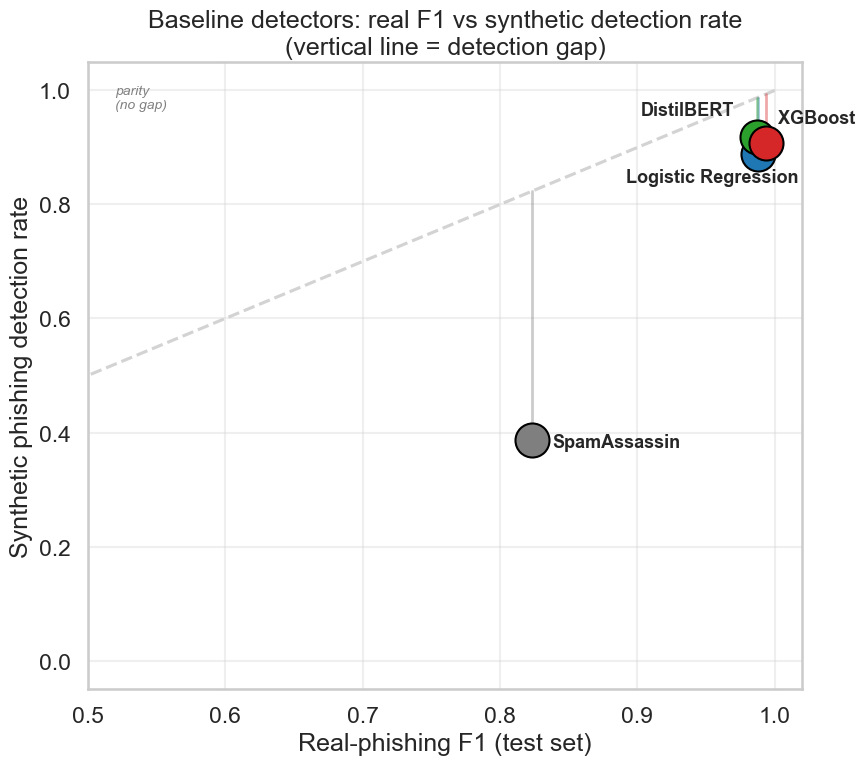


Gap = real recall − synthetic detection rate:
  SpamAssassin           gap = +0.3242  (real recall 0.7115, synth rate 0.3873)
  Logistic Regression    gap = +0.0919  (real recall 0.9804, synth rate 0.8884)
  XGBoost                gap = +0.0603  (real recall 0.9793, synth rate 0.9190)
  DistilBERT             gap = +0.0867  (real recall 0.9948, synth rate 0.9081)


In [17]:
baseline_only = headline[headline["mode"] == "baseline"].copy()

fig, ax = plt.subplots(figsize=(9, 8))

# Parity line
ax.plot([0, 1], [0, 1], "--", color="lightgrey", zorder=0)

# Manual label offsets per detector — prevents overlap when several detectors
# cluster near (1, 1). Offset is in display points.
LABEL_OFFSETS = {
    "spamassassin":         (15, -5),
    "logistic_regression":  (-95, -20),
    "xgboost":              (15, 10),
    "distilbert":           (-90, 20),
}

for _, r in baseline_only.iterrows():
    det = r["detector"]
    ax.scatter(r["real_f1"], r["synth_detection_rate"],
               s=600, color=DETECTOR_COLORS[det],
               edgecolor="black", linewidth=1.5, zorder=3)
    ax.annotate(
        DETECTOR_LABEL[det],
        (r["real_f1"], r["synth_detection_rate"]),
        xytext=LABEL_OFFSETS.get(det, (10, 10)),
        textcoords="offset points",
        fontsize=13, fontweight="bold",
        zorder=4,
    )

# Arrows showing the detection gap — drop a vertical line from each point to the parity line
for _, r in baseline_only.iterrows():
    det = r["detector"]
    ax.plot([r["real_f1"], r["real_f1"]],
            [r["synth_detection_rate"], r["real_f1"]],
            color=DETECTOR_COLORS[det], alpha=0.4, linewidth=2, zorder=1)

ax.set_xlim(0.5, 1.02)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Real-phishing F1 (test set)")
ax.set_ylabel("Synthetic phishing detection rate")
ax.set_title("Baseline detectors: real F1 vs synthetic detection rate\n(vertical line = detection gap)")
ax.grid(True, alpha=0.3)
ax.text(0.52, 0.97, "parity\n(no gap)", fontsize=10, color="grey",
        style="italic")

plt.tight_layout()
plt.savefig(FIGS / "fig1_real_vs_synth.png")
plt.show()

# Print the numbers inline
print("\nGap = real recall − synthetic detection rate:")
for _, r in baseline_only.iterrows():
    print(f"  {DETECTOR_LABEL[r['detector']]:<22} gap = {r['detection_gap']:+.4f}  "
          f"(real recall {r['real_recall']:.4f}, synth rate {r['synth_detection_rate']:.4f})")

## 4. Where the gap lives — breakdown by generation method

Synthetic phishing was generated three ways, simulating increasing attacker sophistication:
- **zero_shot** — LLM prompted with no phishing examples (low-effort attacker)
- **few_shot** — LLM prompted with real phishing examples (attacker has a phishing corpus)
- **rephrasing** — LLM polishes real phishing emails (attacker iterates on proven attacks)

The method that evades most tells us what kind of AI-generated phishing is hardest to catch.

### Figure 2 — Detection rate by method, baseline detectors

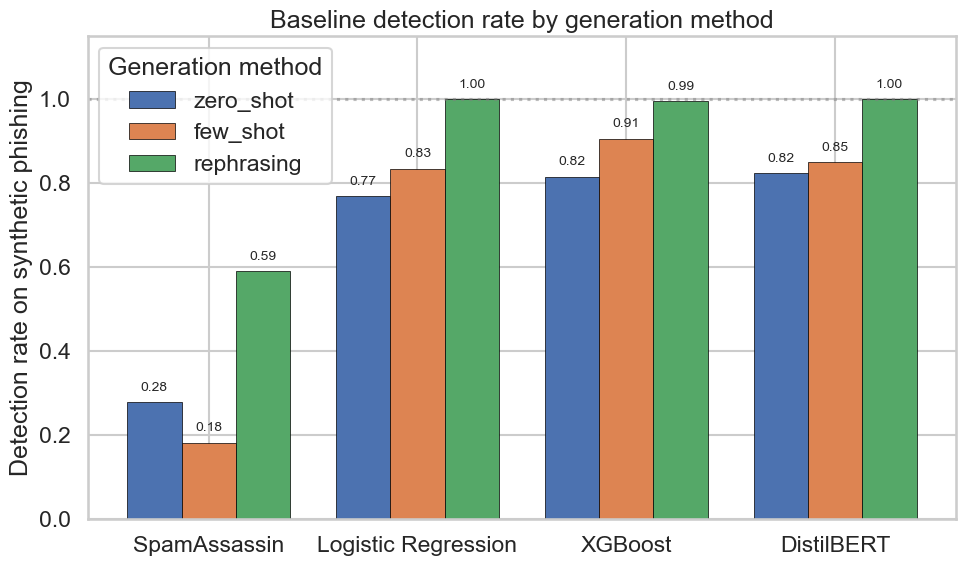


Baseline detection rate by method:
group_value          zero_shot  few_shot  rephrasing
detector                                            
spamassassin            0.2769    0.1811      0.5900
logistic_regression     0.7692    0.8346      1.0000
xgboost                 0.8154    0.9055      0.9950
distilbert              0.8231    0.8504      1.0000


In [18]:
by_method = gaps[(gaps["grouping"] == "method") & (gaps["mode"] == "baseline")].copy()

# Pivot for plotting
pivot = by_method.pivot_table(
    index="detector", columns="group_value", values="detection_rate", aggfunc="first",
).reindex(index=DETECTOR_ORDER)

# Consistent method order
method_order = ["zero_shot", "few_shot", "rephrasing"]
pivot = pivot[method_order]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pivot))
width = 0.26

for i, method in enumerate(method_order):
    offset = (i - 1) * width
    values = pivot[method].values
    bars = ax.bar(x + offset, values, width,
                  label=method, edgecolor="black", linewidth=0.5)
    for j, v in enumerate(values):
        if not np.isnan(v):
            ax.text(x[j] + offset, v + 0.02, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([DETECTOR_LABEL[d] for d in pivot.index], rotation=0)
ax.set_ylabel("Detection rate on synthetic phishing")
ax.set_title("Baseline detection rate by generation method")
ax.set_ylim(0, 1.15)
ax.axhline(1.0, linestyle=":", color="grey", alpha=0.5)
ax.legend(title="Generation method", loc="upper left")

plt.tight_layout()
plt.savefig(FIGS / "fig2_by_method_baseline.png")
plt.show()

print("\nBaseline detection rate by method:")
print(pivot.to_string(float_format="%.4f"))

### Figure 3 — Fine-grained heatmap: detection rate by method × scenario

One row per detector/mode pair, one column per (method, scenario). Dark cells are blind spots.

Small-N warning: each method×scenario cell is ≤10 emails in the baseline measurement, so single emails shift percentages by 10 points. Use this for qualitative patterns, not statistical claims.

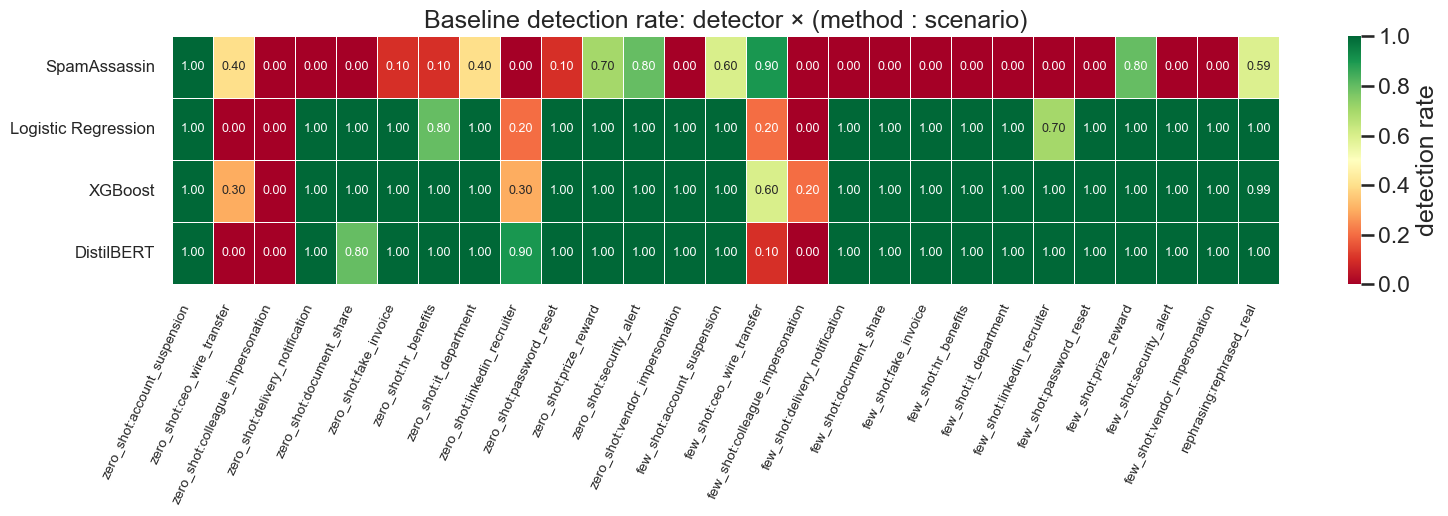

In [19]:
# All four detectors' baseline scenario detection rates
scen_base = gaps[(gaps["grouping"] == "method_scenario") & (gaps["mode"] == "baseline")].copy()

pivot = scen_base.pivot_table(
    index="detector", columns="group_value", values="detection_rate", aggfunc="first",
).reindex(index=DETECTOR_ORDER)
# Drop any all-NaN rows (e.g. detector that never produced method_scenario rows)
pivot = pivot.dropna(how="all")

# Sort columns by method then scenario for readability
method_order_map = {"zero_shot": 0, "few_shot": 1, "rephrasing": 2}
def col_sort_key(c):
    method, _, scenario = c.partition(":")
    return (method_order_map.get(method, 99), scenario)
cols_sorted = sorted(pivot.columns, key=col_sort_key)
pivot = pivot[cols_sorted]

fig, ax = plt.subplots(figsize=(max(16, 0.55 * len(pivot.columns)), 5.5))
sns.heatmap(
    pivot, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1,
    cbar_kws={"label": "detection rate"},
    linewidths=0.4, linecolor="white",
    annot_kws={"fontsize": 9},
    ax=ax,
)
ax.set_yticklabels([DETECTOR_LABEL[d] for d in pivot.index], rotation=0, fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Baseline detection rate: detector × (method : scenario)")
plt.setp(ax.get_xticklabels(), rotation=65, ha="right", fontsize=10)
plt.tight_layout()
plt.savefig(FIGS / "fig3_heatmap_baseline.png")
plt.show()

## 5. Phase 4 — Does augmentation close the gap?

We retrained the three ML detectors on real phishing + 228 synthetic phishing emails (5.6% of phishing training data), then evaluated on a held-out 229-row synthetic test set.

Two questions:
1. **Did the gap close?** — detection rate on held-out synthetic should jump
2. **Did it hurt real detection?** — real-test F1 should stay the same or improve

SpamAssassin is rule-based and not retrained, so it's excluded from this comparison.

### Figure 4 — Before/after augmentation on synthetic phishing

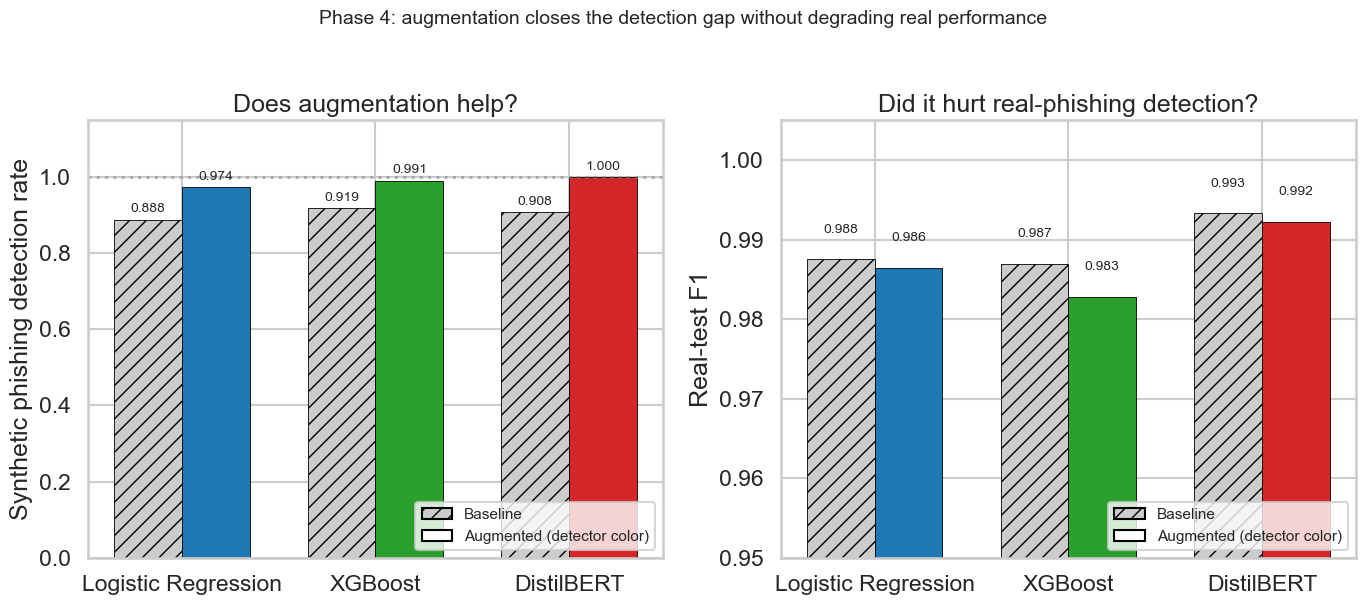


Augmentation effect summary:
  Logistic Regression    synth 0.8884 → 0.9738 (+0.0854),  real F1 0.9875 → 0.9865 (-0.0010)
  XGBoost                synth 0.9190 → 0.9913 (+0.0722),  real F1 0.9870 → 0.9828 (-0.0042)
  DistilBERT             synth 0.9081 → 1.0000 (+0.0919),  real F1 0.9933 → 0.9922 (-0.0010)


In [20]:
ml_head = headline[headline["detector"].isin(ML_DETECTORS)].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: synthetic detection rate, baseline vs augmented
x = np.arange(len(ML_DETECTORS))
width = 0.35
baseline_vals = [ml_head[(ml_head.detector == d) & (ml_head["mode"] == "baseline")]
                 ["synth_detection_rate"].iloc[0] for d in ML_DETECTORS]
aug_vals = [ml_head[(ml_head.detector == d) & (ml_head["mode"] == "augmented")]
            ["synth_detection_rate"].iloc[0] for d in ML_DETECTORS]

b1 = ax1.bar(x - width/2, baseline_vals, width,
             color="#cccccc", edgecolor="black", linewidth=0.6,
             hatch="//", label="Baseline (no synthetic training)")
b2 = ax1.bar(x + width/2, aug_vals, width,
             color=[DETECTOR_COLORS[d] for d in ML_DETECTORS],
             edgecolor="black", linewidth=0.6,
             label="Augmented (+228 synthetic)")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.012,
                 f"{h:.3f}", ha="center", va="bottom", fontsize=10)

ax1.set_xticks(x)
ax1.set_xticklabels([DETECTOR_LABEL[d] for d in ML_DETECTORS])
ax1.set_ylabel("Synthetic phishing detection rate")
ax1.set_title("Does augmentation help?")
ax1.set_ylim(0, 1.15)
ax1.axhline(1.0, linestyle=":", color="grey", alpha=0.5)
# Custom legend: a grey hatched patch for baseline, a plain patch for augmented
from matplotlib.patches import Patch
handles = [
    Patch(facecolor="#cccccc", edgecolor="black", hatch="//",
          label="Baseline"),
    Patch(facecolor="#ffffff", edgecolor="black",
          label="Augmented (detector color)"),
]
ax1.legend(handles=handles, loc="lower right", fontsize=11)

# Right: real F1, baseline vs augmented (the sanity check)
base_f1 = [ml_head[(ml_head.detector == d) & (ml_head["mode"] == "baseline")]
           ["real_f1"].iloc[0] for d in ML_DETECTORS]
aug_f1 = [ml_head[(ml_head.detector == d) & (ml_head["mode"] == "augmented")]
          ["real_f1"].iloc[0] for d in ML_DETECTORS]

b1 = ax2.bar(x - width/2, base_f1, width,
             color="#cccccc", edgecolor="black", linewidth=0.6, hatch="//")
b2 = ax2.bar(x + width/2, aug_f1, width,
             color=[DETECTOR_COLORS[d] for d in ML_DETECTORS],
             edgecolor="black", linewidth=0.6)

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                 f"{h:.3f}", ha="center", va="bottom", fontsize=10)

ax2.set_xticks(x)
ax2.set_xticklabels([DETECTOR_LABEL[d] for d in ML_DETECTORS])
ax2.set_ylabel("Real-test F1")
ax2.set_title("Did it hurt real-phishing detection?")
ax2.set_ylim(0.95, 1.005)
ax2.legend(handles=handles, loc="lower right", fontsize=11)

plt.suptitle("Phase 4: augmentation closes the detection gap without degrading real performance",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "fig4_augmentation.png")
plt.show()

# Summary
print("\nAugmentation effect summary:")
for d in ML_DETECTORS:
    b = ml_head[(ml_head.detector == d) & (ml_head["mode"] == "baseline")].iloc[0]
    a = ml_head[(ml_head.detector == d) & (ml_head["mode"] == "augmented")].iloc[0]
    print(f"  {DETECTOR_LABEL[d]:<22} "
          f"synth {b['synth_detection_rate']:.4f} → {a['synth_detection_rate']:.4f} "
          f"(+{a['synth_detection_rate']-b['synth_detection_rate']:.4f}),  "
          f"real F1 {b['real_f1']:.4f} → {a['real_f1']:.4f} "
          f"({a['real_f1']-b['real_f1']:+.4f})")

### Figure 5 — Augmentation effect by method

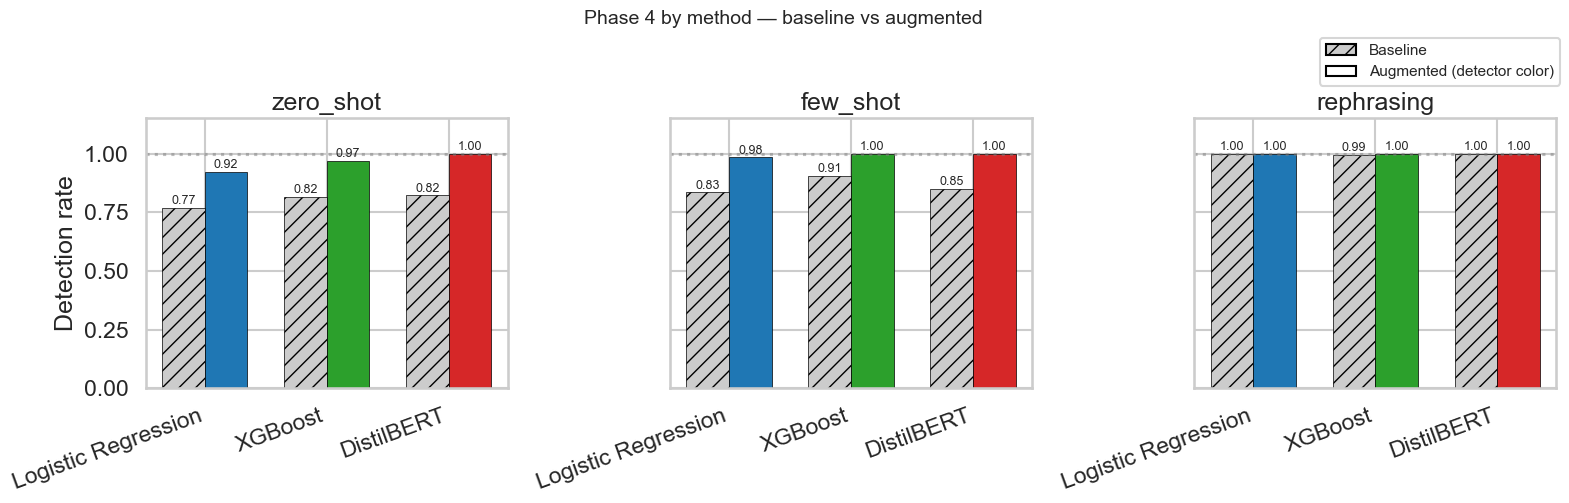

In [21]:
# For each ML detector, compare detection rate per method: baseline vs augmented
by_method_all = gaps[(gaps["grouping"] == "method") & (gaps["detector"].isin(ML_DETECTORS))].copy()

# Pivot: rows = detector, cols = (mode, method)
pivot = by_method_all.pivot_table(
    index="detector", columns=["mode", "group_value"],
    values="detection_rate", aggfunc="first",
).reindex(index=ML_DETECTORS)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
methods = ["zero_shot", "few_shot", "rephrasing"]

for ax, method in zip(axes, methods):
    x = np.arange(len(ML_DETECTORS))
    width = 0.35
    base = [pivot.loc[d, ("baseline", method)] if ("baseline", method) in pivot.columns
            else np.nan for d in ML_DETECTORS]
    aug = [pivot.loc[d, ("augmented", method)] if ("augmented", method) in pivot.columns
           else np.nan for d in ML_DETECTORS]
    ax.bar(x - width/2, base, width,
           color="#cccccc", edgecolor="black", linewidth=0.5, hatch="//")
    ax.bar(x + width/2, aug, width,
           color=[DETECTOR_COLORS[d] for d in ML_DETECTORS],
           edgecolor="black", linewidth=0.5)
    for i, (bv, av) in enumerate(zip(base, aug)):
        if not np.isnan(bv):
            ax.text(i - width/2, bv + 0.015, f"{bv:.2f}", ha="center", fontsize=9)
        if not np.isnan(av):
            ax.text(i + width/2, av + 0.015, f"{av:.2f}", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([DETECTOR_LABEL[d] for d in ML_DETECTORS],
                       rotation=20, ha="right")
    ax.set_title(method)
    ax.set_ylim(0, 1.15)
    ax.axhline(1.0, linestyle=":", color="grey", alpha=0.5)
    if ax is axes[0]:
        ax.set_ylabel("Detection rate")

# Single shared legend
from matplotlib.patches import Patch
handles = [
    Patch(facecolor="#cccccc", edgecolor="black", hatch="//", label="Baseline"),
    Patch(facecolor="#ffffff", edgecolor="black", label="Augmented (detector color)"),
]
fig.legend(handles=handles, loc="upper right", fontsize=11,
           bbox_to_anchor=(0.99, 0.98))

plt.suptitle("Phase 4 by method — baseline vs augmented", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "fig5_augmentation_by_method.png")
plt.show()

## 6. Summary table for the writeup

The headline numbers, one row per (detector, mode). This is what goes in the paper's main result table.

In [22]:
# Format the headline table for readability
out = headline[["detector", "mode", "n_real_test", "real_f1", "real_recall",
                "n_synth", "synth_caught", "synth_detection_rate",
                "detection_gap"]].copy()
out["detector"] = out["detector"].map(DETECTOR_LABEL)
# Round floats
for c in ["real_f1", "real_recall", "synth_detection_rate", "detection_gap"]:
    out[c] = out[c].round(4)

out.to_csv(FIGS.parent / "summary" / "headline_table.csv" if (FIGS.parent / "summary").exists()
           else FIGS.parent / "headline_table.csv", index=False)

print("Headline table:")
out

Headline table:


,detector,mode,n_real_test,real_f1,real_recall,n_synth,synth_caught,synth_detection_rate,detection_gap
0,SpamAssassin,baseline,2647,0.8230,0.7115,457,177,0.3873,0.3242
1,Logistic Regression,baseline,2647,0.9875,0.9804,457,406,0.8884,0.0919
2,Logistic Regression,augmented,2647,0.9865,0.9804,229,223,0.9738,0.0066
3,XGBoost,baseline,2647,0.9870,0.9793,457,420,0.9190,0.0603
4,XGBoost,augmented,2647,0.9828,0.9741,229,227,0.9913,-0.0171
5,DistilBERT,baseline,2647,0.9933,0.9948,457,415,0.9081,0.0867
6,DistilBERT,augmented,2647,0.9922,0.9928,229,229,1.0000,-0.0072


## 7. Key findings

**Phase 3 (attack result):**
- SpamAssassin, tuned to the F1-optimal threshold on real training data (analogous to how the ML detectors use training data), catches only ~39% of AI-generated phishing despite catching ~71% of real phishing — a **32-point detection gap**. The default SA threshold (5.0) is designed for bulk spam, not phishing, and under-recalls severely; we tune to 1.7 for a fair comparison.
- Classical ML detectors (LR, XGBoost) hold up much better than expected, catching 88–92% of synthetic phishing with no synthetic training data
- DistilBERT doesn't outperform classical ML on baseline detection rate — suggesting TF-IDF features capture most of the signal needed for this task
- **Few-shot and spear-phishing variants evade rule-based detection most** (18% and 14% caught by SpamAssassin respectively) — the more the LLM polishes away 2000s-era spam vocabulary, the more invisible it becomes to rule-based detection
- Rephrasing-based synthetic phishing retains enough source-email vocabulary that even SpamAssassin catches 59%
- **Universal ML blind spots:** modern business-email-compromise scenarios (CEO wire transfers, colleague impersonation, delivery notifications) evade every ML detector in the baseline, since they have no 2000s-era training data equivalent

**Phase 4 (mitigation result):**
- Adding 228 synthetic phishing examples (~5.6% of training phishing) closes the detection gap for all three ML detectors on held-out synthetic
- DistilBERT reaches **100% detection on held-out synthetic** with minimal real-test degradation (−0.001 F1)
- XGBoost closes the gap to 99.1% synthetic detection, with a small real-test F1 regression of 0.004
- LR closes to 97.4% with no real-test F1 change
- The mitigation works across model architectures (linear, tree-based, transformer)

**Implications:**
- Rule-based filters are catastrophically vulnerable to LLM-generated phishing even when tuned to production specifications — the gap isn't a tuning issue, it's fundamental to how SA's rule set treats content
- ML-based filters are already fairly robust (~90%), and the residual gap closes with a tiny amount of synthetic data augmentation
- The specific scenarios LLMs generate best (polished spear phishing, BEC patterns) are exactly where all detectors struggle most — augmentation with a small synthetic set directly addresses this weakness
- The mitigation is cheap, effective, model-agnostic, and doesn't require architectural changes